In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import torch

from common.loading_real_wave_noise import loading_real_wave_noise
from common.Reading_path_test import loading_paths_from_MAT
from data.Disturbance_generation import Disturbance_generation_from_real_noise
from fxlms.FxLMS_algorithm_v2 import FxLMS, train_fxlms_algorithm
from gfanc.Control_filter_selection import Control_filter_selection
from gfanc.Fixed_filter_noise_cancellation_subfilters import Fixed_filter_controller

print(torch.cuda.is_available())

True


In [46]:
# real noises
mdict = {}
fs = 16000
StepSize = 0.0001

# sound_name1 = '1_Frequency_from_10_to_7950_10s_Hz'
# sound_name2 = "1_Frequency_from_1600_to_2600_10s_Hz"
# waveform1, resample_rate1 = loading_real_wave_noise(folde_name='Real Noise Examples/', sound_name=sound_name1+'.wav')
# waveform2, resample_rate2 = loading_real_wave_noise(folde_name="Real Noise Examples/", sound_name=sound_name2 + ".wav")
# t = 0.5
# waveform = t * waveform1 + (1-t) * waveform2
# folder_name = "Real Noise Examples/"
folder_name = "Real Noise From Dis/20250506_音データ"
sound_name = "A_Ⅲ_1_20250917"
waveform, resample_rate = loading_real_wave_noise(folde_name=folder_name, sound_name=sound_name + ".wav")

In [47]:
Pri_path, Secon_path = loading_paths_from_MAT(folder='Pz and Sz', subfolder='Dongyuan', Pri_path_file_name='Primary_path.mat', Sec_path_file_name='Secondary_path.mat')
Dis, Fx, Re = Disturbance_generation_from_real_noise(fs=fs, Repet=0, wave_form=waveform, Pri_path=Pri_path, Sec_path=Secon_path)
# Dis: disturbance (cotrolled noise)， Fx: fixed-x signal, Re: repeated waveform (primary_noise) Repetition=Repet+1

In [48]:
print(waveform.shape)
print(Dis.shape)
print(Fx.shape)
print(Re.shape)

import matplotlib as mpl

mpl.rcParams['agg.path.chunksize'] = 10000
Time = np.arange(len(Dis))*(1/fs)

torch.Size([1, 160001])
torch.Size([160000])
torch.Size([160000])
torch.Size([160001])


In [ ]:
from gfanc.Control_filter_selection import Load_Pretrained_filters_to_tensor

SFANC_mat = "models/SFANC_Pretrained_Control_filters.mat"

Filter_vector = Load_Pretrained_filters_to_tensor(SFANC_mat)
Filter_vector.shape
# Filter_vector = Filter_vector.numpy()
# Fixed_Cancellation = Fixed_filter_controller(Filter_vector=Filter_vector, fs=fs)
# ErrorSFANC = Fixed_Cancellation.noise_cancellation(Dis=Dis, Fx=Fx)

torch.Size([15, 1024])

The primary nosie has 10 seconds !!!
1 [1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
2 [1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
3 [1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
4 [1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
5 [1 1 1 0 0 0 0 0 0 0 0 0 0 0 0]
6 [1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
7 [1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
8 [1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
9 [1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
10 [1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]


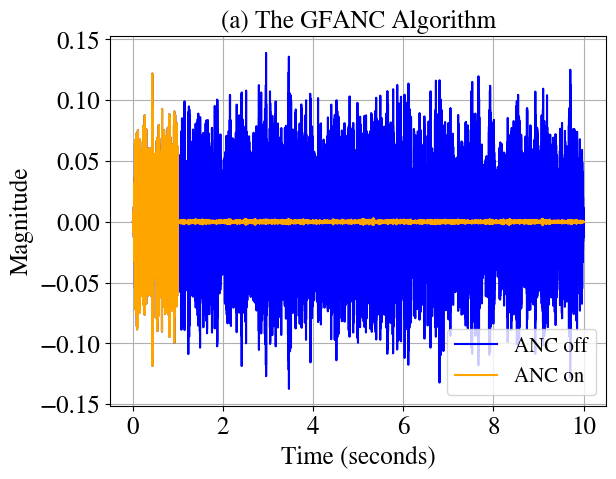

In [ ]:
# GFANC: present frame to predict the next
from gfanc.Control_filter_selection import General_Control_filter_selection

MODEL_PTH = 'models_from_original_dataset/M6_res_Synthetic.pth'
path_mat = 'models/Pretrained_Sub_Control_filters.mat'


# prediction index
Filter_vector = Control_filter_selection(fs=16000, MODEL_PTH=MODEL_PTH, path_mat=path_mat, Primary_noise=Re.unsqueeze(0), threshold=0.5)

Fixed_Cancellation = Fixed_filter_controller(Filter_vector=Filter_vector, fs=16000)
ErrorGFANCoriginal = Fixed_Cancellation.noise_cancellation(Dis=Dis, Fx=Fx)

Time = np.arange(len(Dis))*(1/fs)
Time1 = int(len(Dis)/fs)
plt.rc('font', size=18, family='STIXGeneral') # 将plt画图时字号设置为9字体设置为Times New Roman
plt.rc('axes', titlesize=18) # fontsize of the axes title
plt.rc('axes', labelsize=18) # fontsize of the x and y labels
plt.rc('xtick', labelsize=18) # fontsize of the tick labels
plt.rc('ytick', labelsize=18) # fontsize of the tick labels
plt.rc('legend', fontsize=15) # legend fontsize
plt.rc('figure', titlesize=18) # fontsize of the figure title

plt.title('(a) The GFANC Algorithm')
plt.plot(Time, Dis, color='blue', label='ANC off')
plt.plot(Time, ErrorGFANCoriginal, color='orange', label='ANC on')
plt.ylabel('Magnitude')
plt.xlabel('Time (seconds)')
plt.legend()
plt.grid()
plt.savefig('GFANC.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

The primary nosie has 10 seconds !!!
1 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
2 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
3 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
4 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
5 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
6 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
7 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
8 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
9 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]
10 [1 1 0 0 0 0 0 0 0 0 0 0 0 0 0]


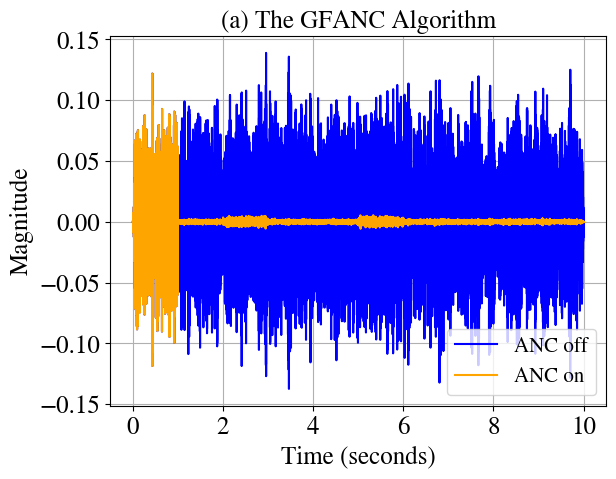

In [ ]:
# GFANC: present frame to predict the next
MODEL_PTH = 'models_from_original_dataset/M6_res_Synthetic_double_Hz_second.pth'
path_mat = 'models/Pretrained_Sub_Control_filters.mat'

# prediction index
Filter_vector = Control_filter_selection(fs=16000, MODEL_PTH=MODEL_PTH, path_mat=path_mat, Primary_noise=Re.unsqueeze(0), threshold=0.5)

Fixed_Cancellation = Fixed_filter_controller(Filter_vector=Filter_vector, fs=16000)
ErrorGFANCnew = Fixed_Cancellation.noise_cancellation(Dis=Dis, Fx=Fx)

Time = np.arange(len(Dis))*(1/fs)
Time1 = int(len(Dis)/fs)

plt.title('(a) The GFANC Algorithm')
plt.plot(Time, Dis, color='blue', label='ANC off')
plt.plot(Time, ErrorGFANCnew, color='orange', label='ANC on')
plt.ylabel('Magnitude')
plt.xlabel('Time (seconds)')
plt.legend()
plt.grid()
plt.savefig('GFANC.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

In [52]:
import torchaudio

torchaudio.save("Helicopter_cancelled_new.wav", ErrorGFANCnew, fs)
torchaudio.save("Helicopter_cancelled_original.wav", ErrorGFANCoriginal, fs)

In [53]:
Leq_original = 10 * np.log10(np.mean(ErrorGFANCoriginal.numpy()**2))
Leq_new = 10 * np.log10(np.mean(ErrorGFANCnew.numpy()**2))
print("improvement = ", Leq_original - Leq_new, "dB")

improvement =  -0.020767212 dB


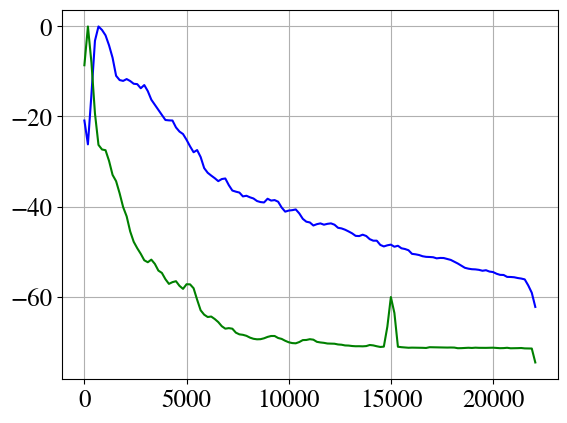

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import torchaudio
from scipy import signal

file = "Dis Noise From Real Noise/20250506_音データ/A_Ⅰ_1_20250917.wav"
wave, fs = torchaudio.load(file)
f, Pxx_den_dis = signal.welch(wave.squeeze().numpy(), fs, scaling="spectrum")
Pxx_dB_dis = 10 * np.log10(Pxx_den_dis / np.max(Pxx_den_dis))
file = "20250506_音データ/A_Ⅰ_1_20250917.wav"
wave, fs = torchaudio.load(file)
wave = wave.mean(dim=0)
f, Pxx_den_ori = signal.welch(wave.squeeze().numpy(), fs, scaling="spectrum")
Pxx_dB_dis = 10 * np.log10(Pxx_den_dis / np.max(Pxx_den_dis))
Pxx_dB_ori = 10 * np.log10(Pxx_den_ori / np.max(Pxx_den_ori))
plt.plot(f, Pxx_dB_dis, color="blue")
plt.plot(f, Pxx_dB_ori, color="green")
plt.grid()

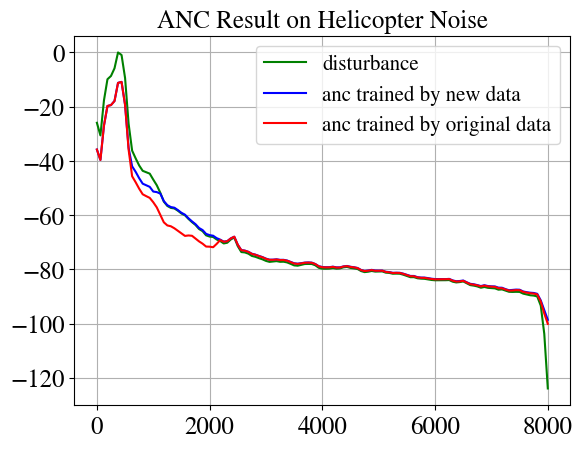

In [54]:
from scipy import signal

f, Pxx_den_dis = signal.welch(Dis, fs, scaling="spectrum")
f, Pxx_den_new = signal.welch(ErrorGFANCnew, fs, scaling="spectrum")
f, Pxx_den_original = signal.welch(ErrorGFANCoriginal, fs, scaling="spectrum")
max = np.max(( Pxx_den_dis, Pxx_den_new, Pxx_den_original))
Pxx_dB_dis = 10 * np.log10(Pxx_den_dis / max)
Pxx_dB_new = 10 * np.log10(Pxx_den_new / max)
Pxx_dB_original = 10 * np.log10(Pxx_den_original / max)
plt.plot(f, Pxx_dB_dis, color="green", label="disturbance")
plt.plot(f, Pxx_dB_new, color="blue", label="anc trained by new data")
plt.plot(f, Pxx_dB_original, color="red", label="anc trained by original data")
plt.title("ANC Result on Helicopter Noise")
plt.legend()
plt.grid()

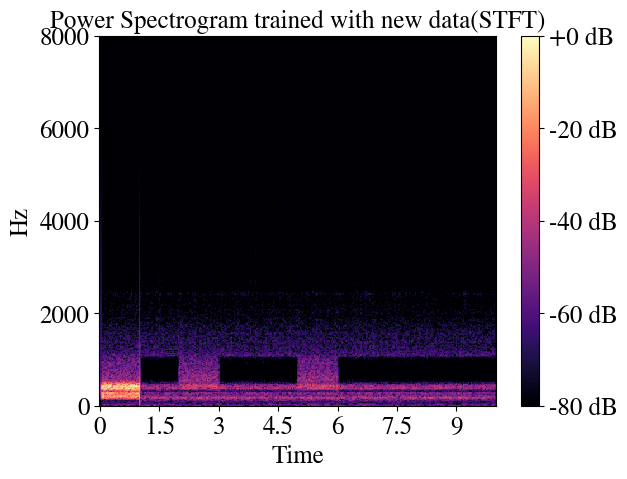

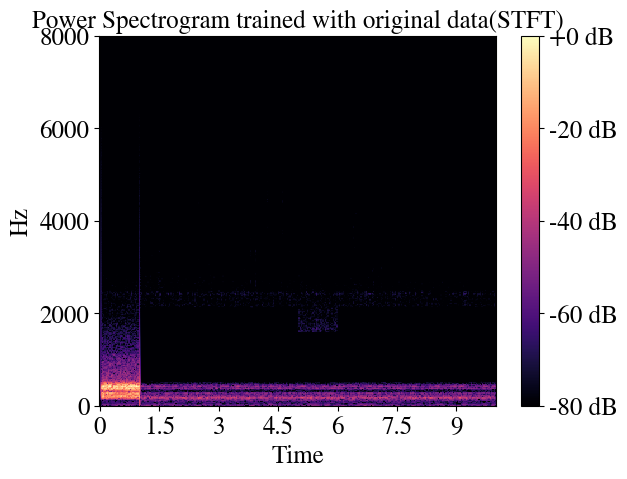

In [55]:
import librosa

db_max = np.max([ ErrorGFANCnew])
y_max = 8000
wave = ErrorGFANCnew.numpy()
stft = librosa.stft(wave, n_fft=1024, hop_length=512)
stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
plt.figure()
librosa.display.specshow(stft_db, sr=fs, x_axis="time", y_axis="linear", cmap="magma")
plt.colorbar(format="%+2.0f dB")
plt.title("Power Spectrogram trained with new data(STFT)")
plt.ylim(0, y_max)
plt.show()
db_max = np.max([ ErrorGFANCoriginal])
y_max = 8000
wave = ErrorGFANCoriginal.numpy()
stft = librosa.stft(wave, n_fft=1024, hop_length=512)
stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
plt.figure()
librosa.display.specshow(stft_db, sr=fs, x_axis="time", y_axis="linear", cmap="magma")
plt.colorbar(format="%+2.0f dB")
plt.title("Power Spectrogram trained with original data(STFT)")
plt.ylim(0, y_max)
plt.show()

/tmp/ipykernel_185163/2235625723.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  dis = np.array(dis)
/tmp/ipykernel_185163/2235625723.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  error = np.array(error)


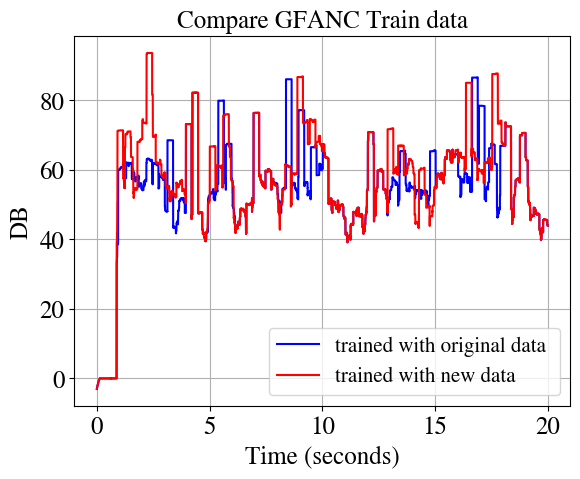

[-5.7587658e-07 -2.8343010e-07  1.4107826e-07 ... -2.6940497e-02
 -2.1570558e-02 -1.5628278e-02]
[-5.7587658e-07 -2.8343010e-07  1.4107826e-07 ... -2.6940497e-02
 -2.1570558e-02 -1.5628278e-02]
24.876968 24.902004


/tmp/ipykernel_185163/2235625723.py:23: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  dis = np.array(dis)
/tmp/ipykernel_185163/2235625723.py:24: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  error = np.array(error)


In [13]:
def sound_pressure_level_smoothed(dis, error, time=0.125, fs=16000):
    dis = np.array(dis)
    error = np.array(error)

    power_ratio = (dis**2) / (error**2)
    window_size = int(time * fs)
    window = np.ones(window_size) / window_size
    smoothed_power_ratio = np.convolve(power_ratio, window, mode='same')
    return 10 * np.log10(smoothed_power_ratio)

level1 = sound_pressure_level_smoothed(Dis, ErrorGFANCoriginal, 0.25)
level2 = sound_pressure_level_smoothed(Dis, ErrorGFANCnew, 0.25)
plt.title('Compare GFANC Train data')
plt.plot(Time, level1, color='blue', label='trained with original data ')
plt.plot(Time, level2, color='red', label='trained with new data ')
plt.ylabel('DB')
plt.xlabel('Time (seconds)')
plt.legend()
plt.grid()
plt.savefig('SFANC_FxNLMS.pdf', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()
def sound_pressure_level_scalar(dis, error):
    dis = np.array(dis)
    error = np.array(error)
    print(dis)
    time = len(dis) / fs
    scalar_power_ratio = np.sum(dis**2) / np.sum(error**2) * time
    
    return 10 * np.log10(scalar_power_ratio)
level1 = sound_pressure_level_scalar(Dis, ErrorGFANCoriginal)
level2 = sound_pressure_level_scalar(Dis, ErrorGFANCnew)
print(level1, level2)

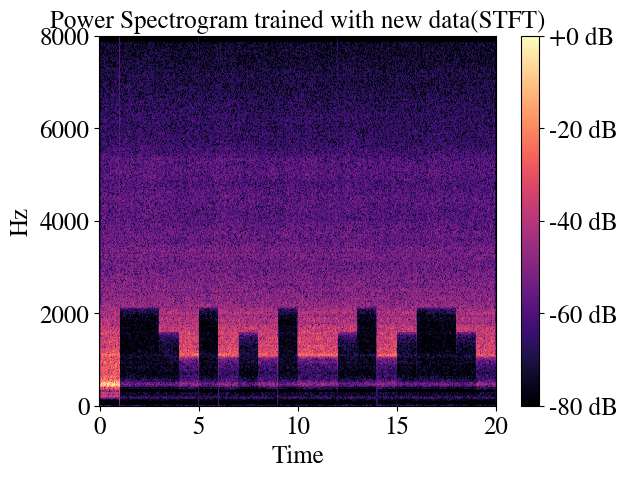

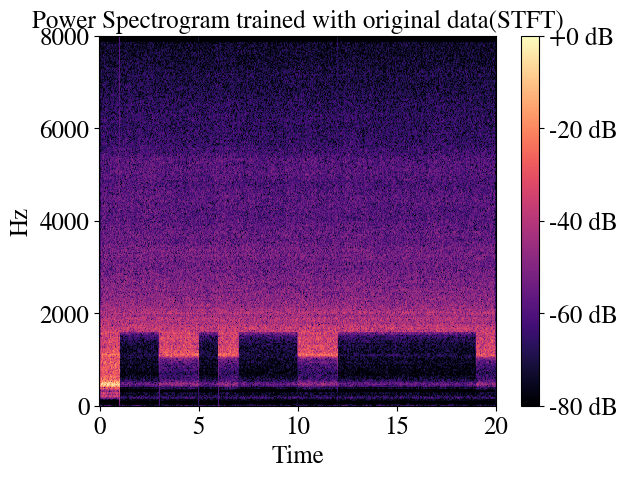

In [17]:
import librosa

db_max = np.max([ ErrorGFANCnew])
y_max = 8000
wave = ErrorGFANCnew.numpy()
stft = librosa.stft(wave, n_fft=1024, hop_length=512)
stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
plt.figure()
librosa.display.specshow(stft_db, sr=fs, x_axis="time", y_axis="linear", cmap="magma")
plt.colorbar(format="%+2.0f dB")
plt.title("Power Spectrogram trained with new data(STFT)")
plt.ylim(0, y_max)
plt.show()
db_max = np.max([ ErrorGFANCoriginal])
y_max = 8000
wave = ErrorGFANCoriginal.numpy()
stft = librosa.stft(wave, n_fft=1024, hop_length=512)
stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
plt.figure()
librosa.display.specshow(stft_db, sr=fs, x_axis="time", y_axis="linear", cmap="magma")
plt.colorbar(format="%+2.0f dB")
plt.title("Power Spectrogram trained with original data(STFT)")
plt.ylim(0, y_max)
plt.show()

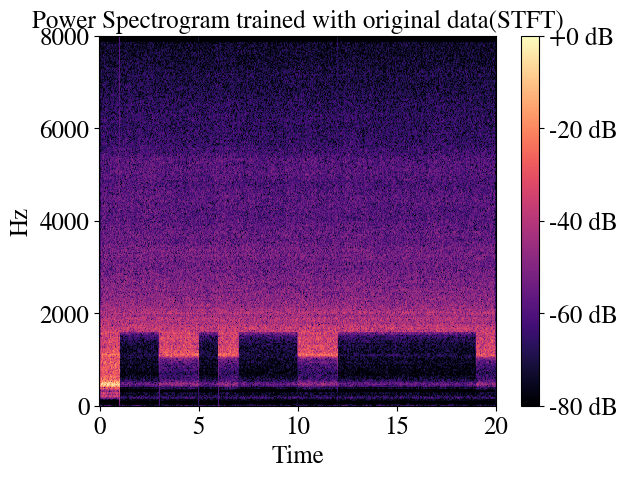

In [15]:
import librosa

db_max = np.max([ ErrorGFANCoriginal])
y_max = 8000
wave = ErrorGFANCoriginal.numpy()
stft = librosa.stft(wave, n_fft=1024, hop_length=512)
stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
plt.figure()
librosa.display.specshow(stft_db, sr=fs, x_axis="time", y_axis="linear", cmap="magma")
plt.colorbar(format="%+2.0f dB")
plt.title("Power Spectrogram trained with original data(STFT)")
plt.ylim(0, y_max)
plt.show()

The primary nosie has 10 seconds !!!
1 [1 1 1 1 1 0 1 0 0 0 0 0 0 0 0]
2 [1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
3 [1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
4 [1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
5 [1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
6 [1 1 1 1 1 0 0 0 0 0 0 0 0 0 0]
7 [1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
8 [1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
9 [1 1 1 1 0 0 0 0 0 0 0 0 0 0 0]
10 [1 1 0 1 0 0 0 0 0 0 0 0 0 0 0]


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

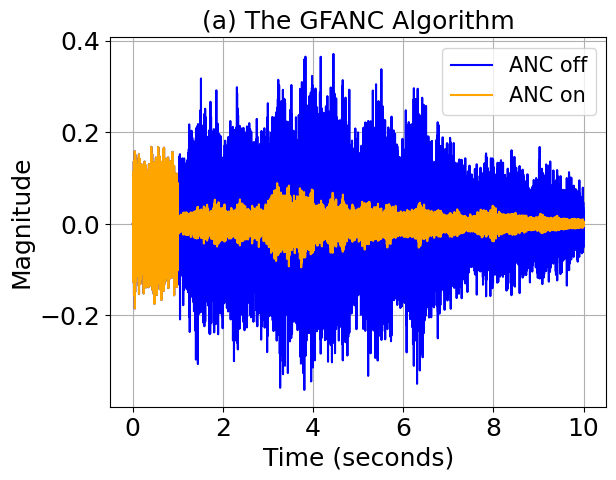

In [ ]:
# GFANC: present frame to predict the next
MODEL_PTH = 'models_from_original_dataset/M6_res_Synthetic_2.pth'
path_mat = 'models/Pretrained_Sub_Control_filters.mat'

# prediction index
Filter_vector = General_Control_filter_selection(fs=16000, MODEL_PTH=MODEL_PTH, path_mat=path_mat, Primary_noise=Re.unsqueeze(0), numclass=2)

Fixed_Cancellation = Fixed_filter_controller(Filter_vector=Filter_vector, fs=16000)
ErrorGFANC = Fixed_Cancellation.noise_cancellation(Dis=Dis, Fx=Fx)

Time = np.arange(len(Dis))*(1/fs)
Time1 = int(len(Dis)/fs)
plt.rc('font', size=18, family='Times New Roman') # 将plt画图时字号设置为9字体设置为Times New Roman
plt.rc('axes', titlesize=18) # fontsize of the axes title
plt.rc('axes', labelsize=18) # fontsize of the x and y labels
plt.rc('xtick', labelsize=18) # fontsize of the tick labels
plt.rc('ytick', labelsize=18) # fontsize of the tick labels
plt.rc('legend', fontsize=15) # legend fontsize
plt.rc('figure', titlesize=18) # fontsize of the figure title

plt.title('(a) The GFANC Algorithm')
plt.plot(Time, Dis, color='blue', label='ANC off')
plt.plot(Time, ErrorGFANC, color='orange', label='ANC on')
plt.ylabel('Magnitude')
plt.xlabel('Time (seconds)')
plt.legend()
plt.grid()
plt.savefig('GFANC.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

The primary nosie has 10 seconds !!!
1 [2 2 2 2 0 0 0 0 0 0 0 0 0 0 0]
2 [2 2 2 2 0 0 0 0 0 0 0 0 0 0 0]
3 [2 2 0 2 0 0 0 0 0 0 0 0 0 0 0]
4 [2 2 2 2 0 0 0 0 0 0 0 0 0 0 0]
5 [2 2 2 2 0 0 0 0 0 0 0 0 0 0 0]
6 [2 2 2 2 0 0 0 0 0 0 0 0 0 0 0]
7 [2 2 2 0 0 0 0 0 0 0 0 0 0 0 0]
8 [2 2 0 0 0 0 0 0 0 0 0 0 0 0 0]
9 [2 2 0 0 0 0 0 0 0 0 0 0 0 0 0]
10 [2 2 0 0 0 0 0 0 0 0 0 0 0 0 0]


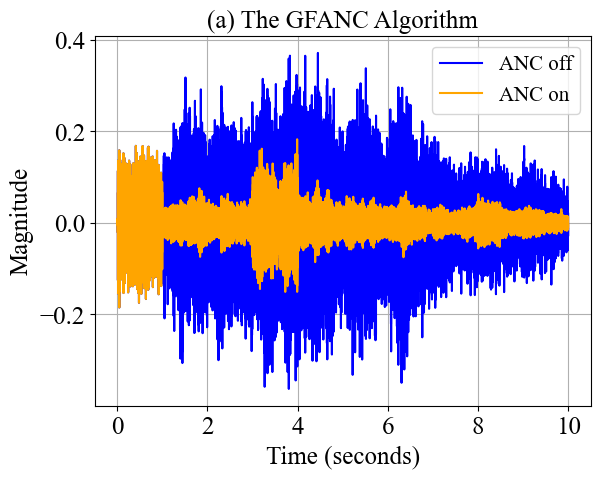

In [ ]:
# GFANC: present frame to predict the next
from gfanc.Control_filter_selection import General_Control_filter_selection

MODEL_PTH = 'models_from_original_dataset/M6_res_Synthetic_3.pth'
path_mat = 'models/Pretrained_Sub_Control_filters.mat'

# prediction index
Filter_vector = General_Control_filter_selection(fs=16000, MODEL_PTH=MODEL_PTH, path_mat=path_mat, Primary_noise=Re.unsqueeze(0), numclass=3)

Fixed_Cancellation = Fixed_filter_controller(Filter_vector=Filter_vector, fs=16000)
ErrorGFANC3 = Fixed_Cancellation.noise_cancellation(Dis=Dis, Fx=Fx)

Time = np.arange(len(Dis))*(1/fs)
Time1 = int(len(Dis)/fs)
plt.rc('font', size=18, family='Times New Roman') # 将plt画图时字号设置为9字体设置为Times New Roman
plt.rc('axes', titlesize=18) # fontsize of the axes title
plt.rc('axes', labelsize=18) # fontsize of the x and y labels
plt.rc('xtick', labelsize=18) # fontsize of the tick labels
plt.rc('ytick', labelsize=18) # fontsize of the tick labels
plt.rc('legend', fontsize=15) # legend fontsize
plt.rc('figure', titlesize=18) # fontsize of the figure title

plt.title('(a) The GFANC Algorithm')
plt.plot(Time, Dis, color='blue', label='ANC off')
plt.plot(Time, ErrorGFANC3, color='orange', label='ANC on')
plt.ylabel('Magnitude')
plt.xlabel('Time (seconds)')
plt.legend()
plt.grid()
plt.savefig('GFANC.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

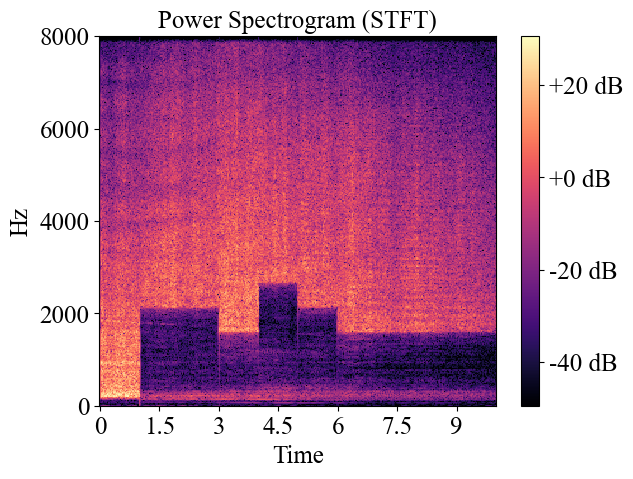

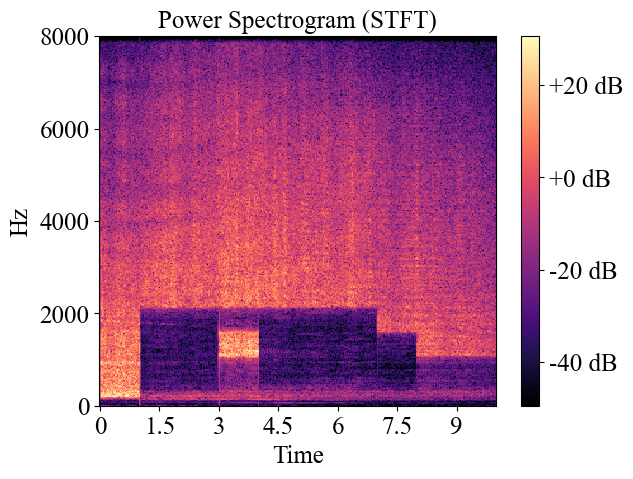

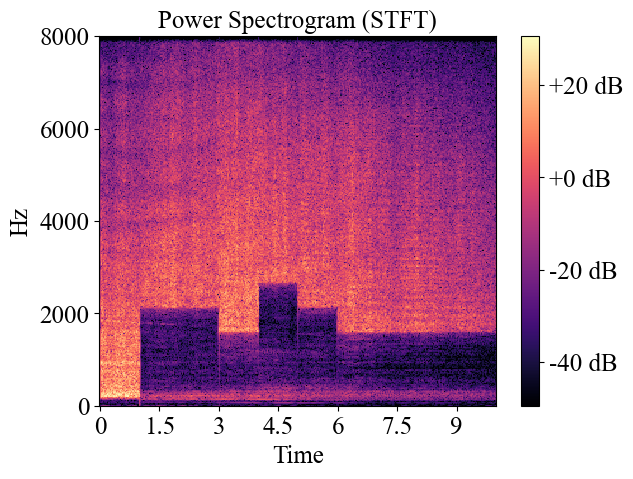

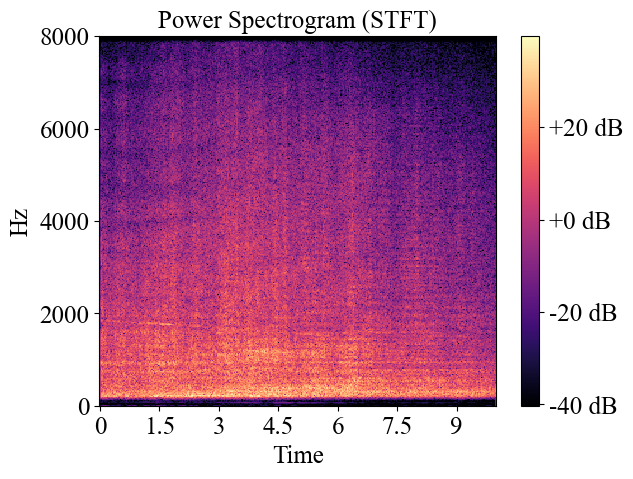

In [58]:
import librosa

db_max = np.max([ErrorGFANC, ErrorGFANC2, Dis])
y_max = 8000
wave = ErrorGFANC2.numpy()
stft = librosa.stft(wave, n_fft=1024, hop_length=512)
stft_db = librosa.amplitude_to_db(np.abs(stft), ref=db_max)
plt.figure()
librosa.display.specshow(stft_db, sr=fs, x_axis="time", y_axis="linear", cmap="magma")
plt.colorbar(format="%+2.0f dB")
plt.title("Power Spectrogram (STFT)")
plt.ylim(0, y_max)
plt.show()
import librosa

wave = ErrorGFANC3.numpy()
stft = librosa.stft(wave, n_fft=1024, hop_length=512)
stft_db = librosa.amplitude_to_db(np.abs(stft), ref=db_max)
plt.figure()
librosa.display.specshow(stft_db, sr=fs, x_axis="time", y_axis="linear", cmap="magma")
plt.colorbar(format="%+2.0f dB")
plt.title("Power Spectrogram (STFT)")
plt.ylim(0, y_max)
plt.show()
import librosa

wave = ErrorGFANC2.numpy()
stft = librosa.stft(wave, n_fft=1024, hop_length=512)
stft_db = librosa.amplitude_to_db(np.abs(stft), ref=db_max)
plt.figure()
librosa.display.specshow(stft_db, sr=fs, x_axis="time", y_axis="linear", cmap="magma")
plt.colorbar(format="%+2.0f dB")
plt.title("Power Spectrogram (STFT)")
plt.ylim(0, y_max)
plt.show()
import librosa

wave = Dis.numpy()
stft = librosa.stft(wave, n_fft=1024, hop_length=512)
stft_db = librosa.amplitude_to_db(np.abs(stft), ref=db_max)
plt.figure()
librosa.display.specshow(stft_db, sr=fs, x_axis="time", y_axis="linear", cmap="magma")
plt.colorbar(format="%+2.0f dB")
plt.title("Power Spectrogram (STFT)")
plt.ylim(0, y_max)
plt.show()

In [55]:
npdis = Dis.numpy()


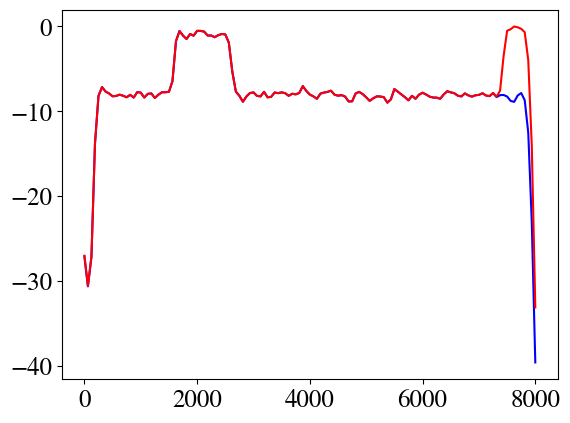

In [175]:
from scipy import signal

f, Pxx_den_new = signal.welch(ErrorGFANCnew, fs, scaling="spectrum")
f, Pxx_den_original = signal.welch(ErrorGFANCoriginal, fs, scaling="spectrum")
max = np.max((Pxx_den_new, Pxx_den_original))
Pxx_dB_new = 10 * np.log10(Pxx_den_new / max)
Pxx_dB_original = 10 * np.log10(Pxx_den_original / max)
plt.plot(f, Pxx_dB_new, color="blue")
plt.plot(f, Pxx_dB_original, color="red")

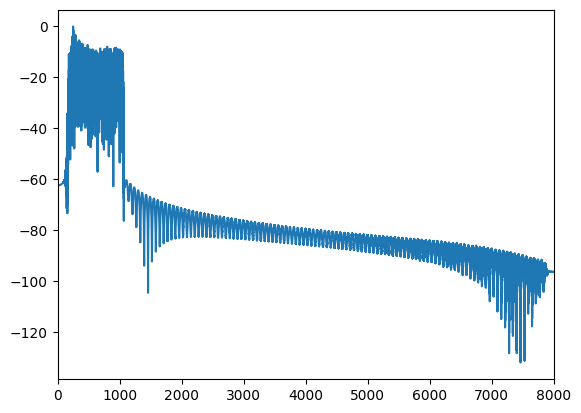

In [16]:
dft = torch.fft.rfft(Dis)
freq = torch.fft.rfftfreq(Dis.shape[0], d=1/fs)
dft_db = 20 * torch.log10(torch.abs(dft)/torch.max(torch.abs(dft)))

plt.figure()
plt.xlim(0, 8000)
plt.plot(freq, dft_db)
plt.show()

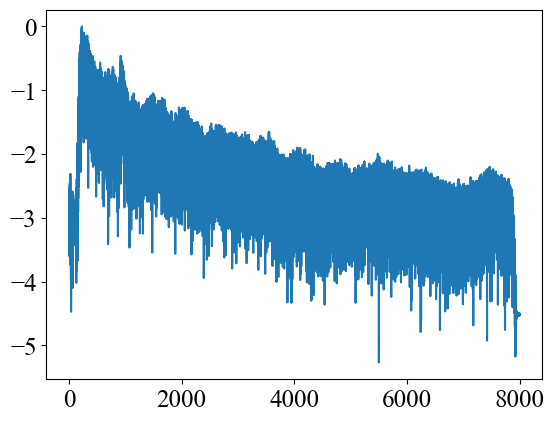

torch.Size([80001])

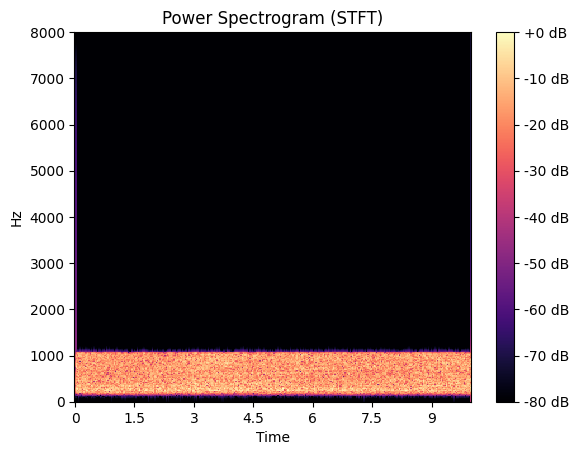

In [24]:
import librosa

wave = Dis.numpy()
stft = librosa.stft(wave, n_fft=1024, hop_length=512)
stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
plt.figure()
librosa.display.specshow(stft_db, sr=fs, x_axis="time", y_axis="linear", cmap="magma")
plt.colorbar(format="%+2.0f dB")
plt.title("Power Spectrogram (STFT)")
plt.ylim(0, 8000)
plt.show()

In [22]:
import librosa

wave = ErrorGFANC2.numpy()
stft = librosa.stft(wave, n_fft=1024, hop_length=512)
stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)
plt.figure()
librosa.display.specshow(stft_db, sr=fs, x_axis="time", y_axis="linear", cmap="magma")
plt.colorbar(format="%+2.0f dB")
plt.title("Power Spectrogram (STFT)")
plt.ylim(0, y_max)
plt.show()

NameError: name 'ErrorGFANC2' is not defined

/tmp/ipykernel_1528244/2309648610.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  dis = np.array(dis)
/tmp/ipykernel_1528244/2309648610.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  error = np.array(error)


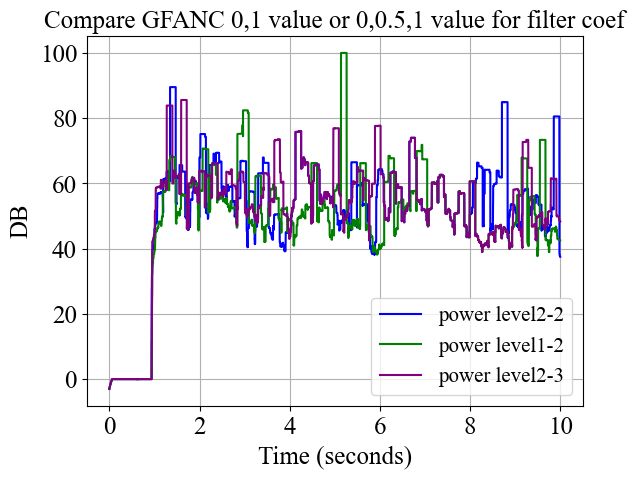

In [ ]:
def sound_pressure_level_smoothed(dis, error, time=0.125, fs=16000):
    dis = np.array(dis)
    error = np.array(error)

    power_ratio = (dis**2) / (error**2)
    window_size = int(time * fs)
    window = np.ones(window_size) / window_size
    smoothed_power_ratio = np.convolve(power_ratio, window, mode='same')
    return 10 * np.log10(smoothed_power_ratio)

level = sound_pressure_level_smoothed(Dis, ErrorGFANC, )
plt.title('Compare GFANC Train data size')
plt.plot(Time, level, color='blue', label='train data size: ' + str(i))
plt.ylabel('DB')
plt.xlabel('Time (seconds)')
plt.legend()
plt.grid()
plt.savefig('SFANC_FxNLMS.pdf', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

In [33]:
# SFANC

from scipy.io import loadmat

mat_contents = loadmat('SFANC_Error.mat')
ErrorSFANC = mat_contents['Error']
ErrorSFANC = ErrorSFANC[0]

FileNotFoundError: [Errno 2] No such file or directory: 'SFANC_Error.mat'

[========================================================================] 100%


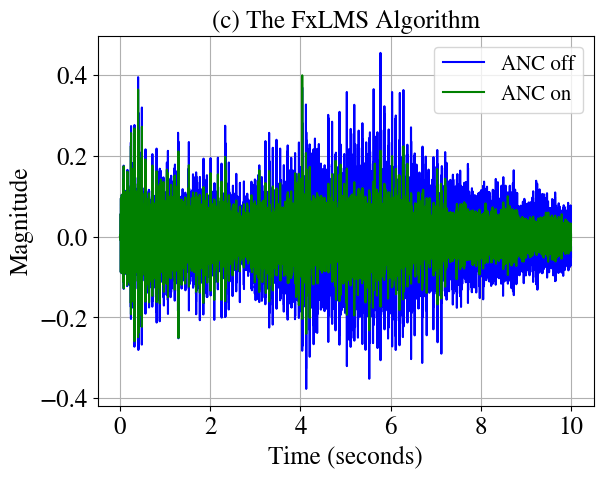

In [62]:
# FxLMS

controller = FxLMS(Len=1024) # 1024 is the same size of coeffient vector of fixed-filter
ErrorFxLMS = train_fxlms_algorithm(Model=controller, Ref=Fx, Disturbance=Dis, Stepsize=StepSize) # torch.Size([320000])

plt.title('(c) The FxLMS Algorithm')
plt.plot(Time, Dis, color='blue', label='ANC off')
plt.plot(Time, ErrorFxLMS, color='green', label='ANC on')
plt.ylabel('Magnitude')
plt.xlabel('Time (seconds)')
plt.legend()
plt.grid()
plt.savefig('FxLMS.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

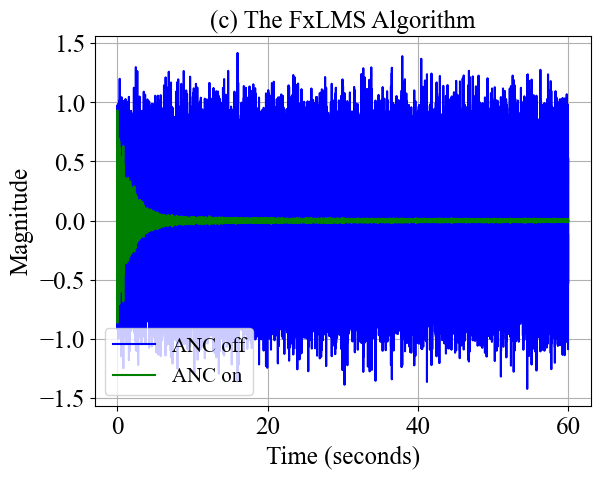

In [30]:
# FxLMS
from FxLMS_algorithm_v2 import NumpyFxLMS, train_numpy_fxlms_algorithm

controller = NumpyFxLMS(Len=1024) # 1024 is the same size of coeffient vector of fixed-filter
ErrorFxLMS = train_numpy_fxlms_algorithm(NumpyModel=controller, Ref=Fx, Disturbance=Dis, Stepsize=StepSize) # torch.Size([320000])

plt.title('(c) The FxLMS Algorithm')
plt.plot(Time, Dis, color='blue', label='ANC off')
plt.plot(Time, ErrorFxLMS, color='green', label='ANC on')
plt.ylabel('Magnitude')
plt.xlabel('Time (seconds)')
plt.legend()
plt.grid()
plt.savefig('FxLMS.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

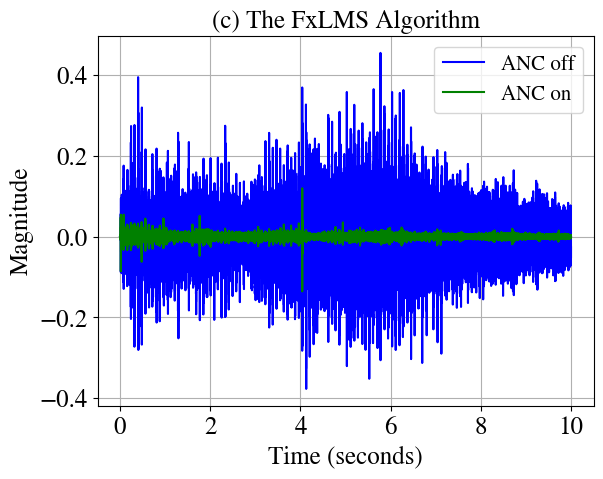

In [65]:
from FxLMS_algorithm_v2 import SuperFastLMS, train_fast_lms_algorithm

controller = SuperFastLMS(Len=1024) # 1024 is the same size of coeffient vector of fixed-filter
ErrorFxLMS = train_fast_lms_algorithm(Model=controller, Ref=Fx, Disturbance=Dis, Stepsize=2000 * StepSize) # torch.Size([320000])

plt.title('(c) The FxLMS Algorithm')
plt.plot(Time, Dis, color='blue', label='ANC off')
plt.plot(Time, ErrorFxLMS, color='green', label='ANC on')
plt.ylabel('Magnitude')
plt.xlabel('Time (seconds)')
plt.legend()
plt.grid()
plt.savefig('FxLMS.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

In [ ]:
import torch

a = torch.tensor([1, 2,3, 4,5 ])
b = torch.flip(a, dims=[0])
R = b.as_strided(
    size=(5, 5),
    stride=(1, 1),
    storage_offset=0
)
R

RuntimeError: setStorage: sizes [5, 5], strides [1, 1], storage offset 0, and itemsize 8 requiring a storage size of 72 are out of bounds for storage of size 40

In [7]:
torch.cuda.is_available()

True

In [27]:
Dis.shape

torch.Size([960000])

In [5]:

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Fx = Fx.to(device)
# Dis = Dis.to(device)
N = Dis.shape[0]
M = 1024
r_flipped = torch.flip(Fx, dims=[0]).contiguous()
R = r_flipped.unfold(0, M, 1)
R = torch.flip(R, dims=[0]).contiguous()
R.to(device)

d_vec = Dis[M-1:].unsqueeze(1)
d_vec.to(device)
c = torch.linalg.lstsq(R, d_vec)

In [23]:
filter = c.solution.squeeze()

In [ ]:
filter

torch.Size([1024])

tensor([ 0.0134, -0.0185, -0.0005,  ...,  0.0023, -0.0022,  0.0003])

In [25]:

Error = Dis[M-1:] + R @ filter
Error = Error.squeeze().squeeze()
Time = np.arange(len(Error))*(1/fs)
output = Dis[M-1:]

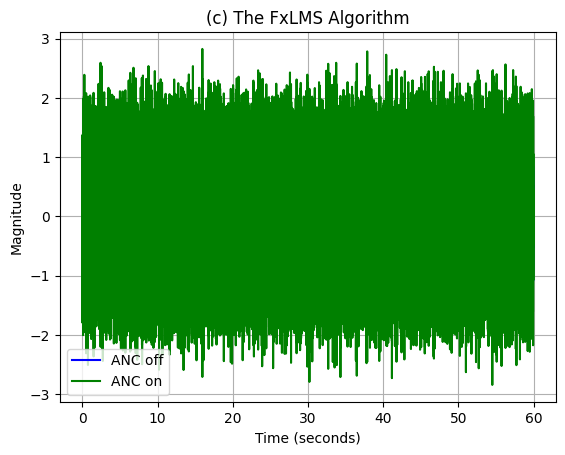

In [26]:
plt.title('(c) The FxLMS Algorithm')
plt.plot(Time, output, color='blue', label='ANC off')
plt.plot(Time, Error, color='green', label='ANC on')
plt.ylabel('Magnitude')
plt.xlabel('Time (seconds)')
plt.legend()
plt.grid()
plt.savefig('FxLMS.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

/tmp/ipykernel_2932777/1792059432.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  dis = np.array(dis)


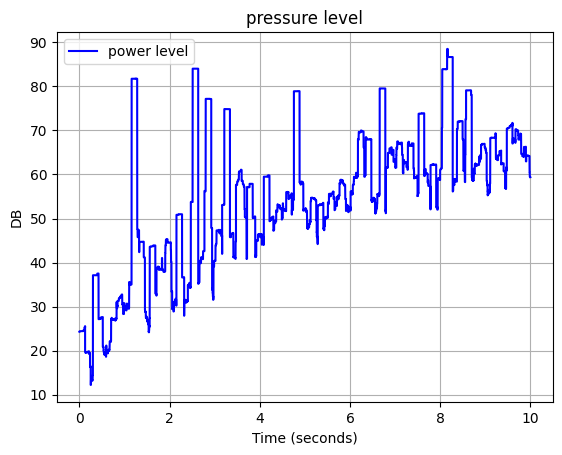

In [32]:
def sound_pressure_level_smoothed(dis, error, time=0.125, fs=16000):
    dis = np.array(dis)
    error = np.array(error)

    power_ratio = (dis**2) / (error**2)
    window_size = int(time * fs)
    window = np.ones(window_size) / window_size
    smoothed_power_ratio = np.convolve(power_ratio, window, mode='same')
    return 10 * np.log10(smoothed_power_ratio)
level = sound_pressure_level_smoothed(Dis, ErrorFxLMS, 0.125)
# level2 = sound_pressure_level_smoothed(Dis, ErrorGFANC2, 1)
plt.title('pressure level')
plt.plot(Time, level, color='blue', label='power level')
# plt.plot(Time, level2, color="green", label="power level2")
plt.ylabel('DB')
plt.xlabel('Time (seconds)')
plt.legend()
plt.grid()
plt.savefig('SFANC_FxNLMS.pdf', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

/tmp/ipykernel_1920244/168695048.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  dis = np.array(dis)
/tmp/ipykernel_1920244/168695048.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  error = np.array(error)
/tmp/ipykernel_1920244/168695048.py:5: RuntimeWarning: divide by zero encountered in divide
  power_ratio = (dis**2) / (error**2)


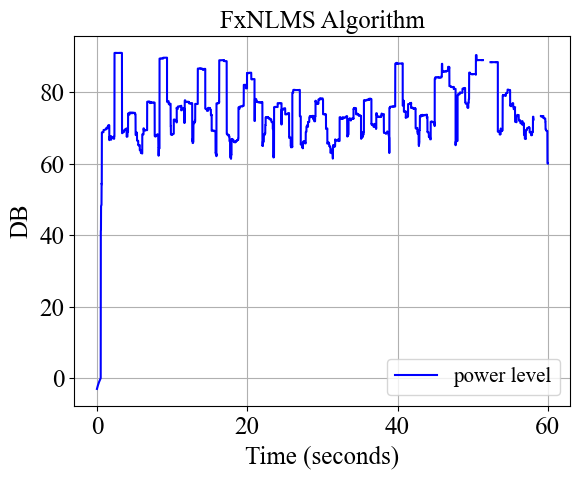

In [32]:
def sound_pressure_level_smoothed(dis, error, time=0.125, fs=16000):
    dis = np.array(dis)
    error = np.array(error)

    power_ratio = (dis**2) / (error**2)
    window_size = int(time * fs)
    window = np.ones(window_size) / window_size
    smoothed_power_ratio = np.convolve(power_ratio, window, mode='same')
    return 10 * np.log10(smoothed_power_ratio)
level = sound_pressure_level_smoothed(Dis, ErrorGFANC, 1)
plt.title('FxNLMS Algorithm')
plt.plot(Time, level, color='blue', label='power level')
plt.ylabel('DB')
plt.xlabel('Time (seconds)')
plt.legend()
plt.grid()
plt.savefig('SFANC_FxNLMS.pdf', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

In [1]:
def plot_specgram(waveform, sample_rate, filepath, title="Spectrogram", xlim=None):
    waveform = waveform.numpy()

    num_channels, num_frames = waveform.shape
    time_axis = torch.arange(0, num_frames) / sample_rate

    figure, axes = plt.subplots(num_channels, 1)
    if num_channels == 1:
        axes = [axes]
    for c in range(num_channels):
        axes[c].specgram(waveform[c], Fs=sample_rate)
        if num_channels > 1:
            axes[c].set_ylabel(f'Channel {c+1}')
        if xlim:
            axes[c].set_xlim(xlim)
    figure.suptitle(title)
    plt.savefig(filepath)
    plt.close('all')

In [35]:
wave = torch.tensor(ErrorGFANC).unsqueeze(0)
plot_specgram(wave, fs, "spec")


/tmp/ipykernel_1920244/2591309485.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  wave = torch.tensor(ErrorGFANC).unsqueeze(0)


In [76]:
# compare the Noise_Reduction_Level in every second

def Noise_Reduction_Level_Compute(Disturbance, Error):
    Power_dis = 10*np.log10(np.var(Disturbance))
    Power_err = 10*np.log10(np.var(Error))
    NR_level = Power_dis - Power_err
    return NR_level

if torch.is_tensor(Dis):
    Dis = Dis.numpy() # tensor to numpy
if torch.is_tensor(ErrorGFANC):
    ErrorGFANC = ErrorGFANC.numpy()

a, b, c = [], [], []
a.append(Dis[0])
b.append(Dis[0])
c.append(Dis[0])
Time1 = int(len(Dis)/fs)
for t in range(Time1):
    a.append(Noise_Reduction_Level_Compute(Dis[t*fs:(t+1)*fs], ErrorGFANC[t*fs:(t+1)*fs]))
    b.append(Noise_Reduction_Level_Compute(Dis[t*fs:(t+1)*fs], ErrorSFANC[t*fs:(t+1)*fs]))
    c.append(Noise_Reduction_Level_Compute(Dis[t*fs:(t+1)*fs], ErrorFxLMS[t*fs:(t+1)*fs]))
    
plt.title('(d) Averaged Noise Reduction Level of Every 1s')
plt.step(range(Time1+1), c, color='green', label='FxLMS')
plt.step(range(Time1+1), b, color='blue', label='SFANC')
plt.step(range(Time1+1), a, color='red', label='GFANC')
plt.ylabel('Noise Reduction Level (dB)')
plt.xlabel('Time (seconds)')
plt.xticks(range(0, Time1+1, 1)) # the interval in x
plt.legend()
plt.grid()
plt.savefig('Noise_Reduction_Level.png', dpi=600, bbox_inches='tight', pad_inches=0)
plt.show()

NameError: name 'ErrorSFANC' is not defined